In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

# Imports

In [3]:
from harp.data import generate_data

import yaml

# Data Pipeline

Starting Data Generation Pipeline with Random State: 42
... Collecting and Cleaning Data


... Splitting Data (Train/Val/Test)
... Injecting Rejected Claims (Rate: 0.2)
... Calculating Global Complexity Cutoffs
Data Per-Reviewer Distribution
Reviewer 1 (Score 0.0 - 3.61): 314099 claims
Reviewer 2 (Score 3.61 - 10.0): 77881 claims


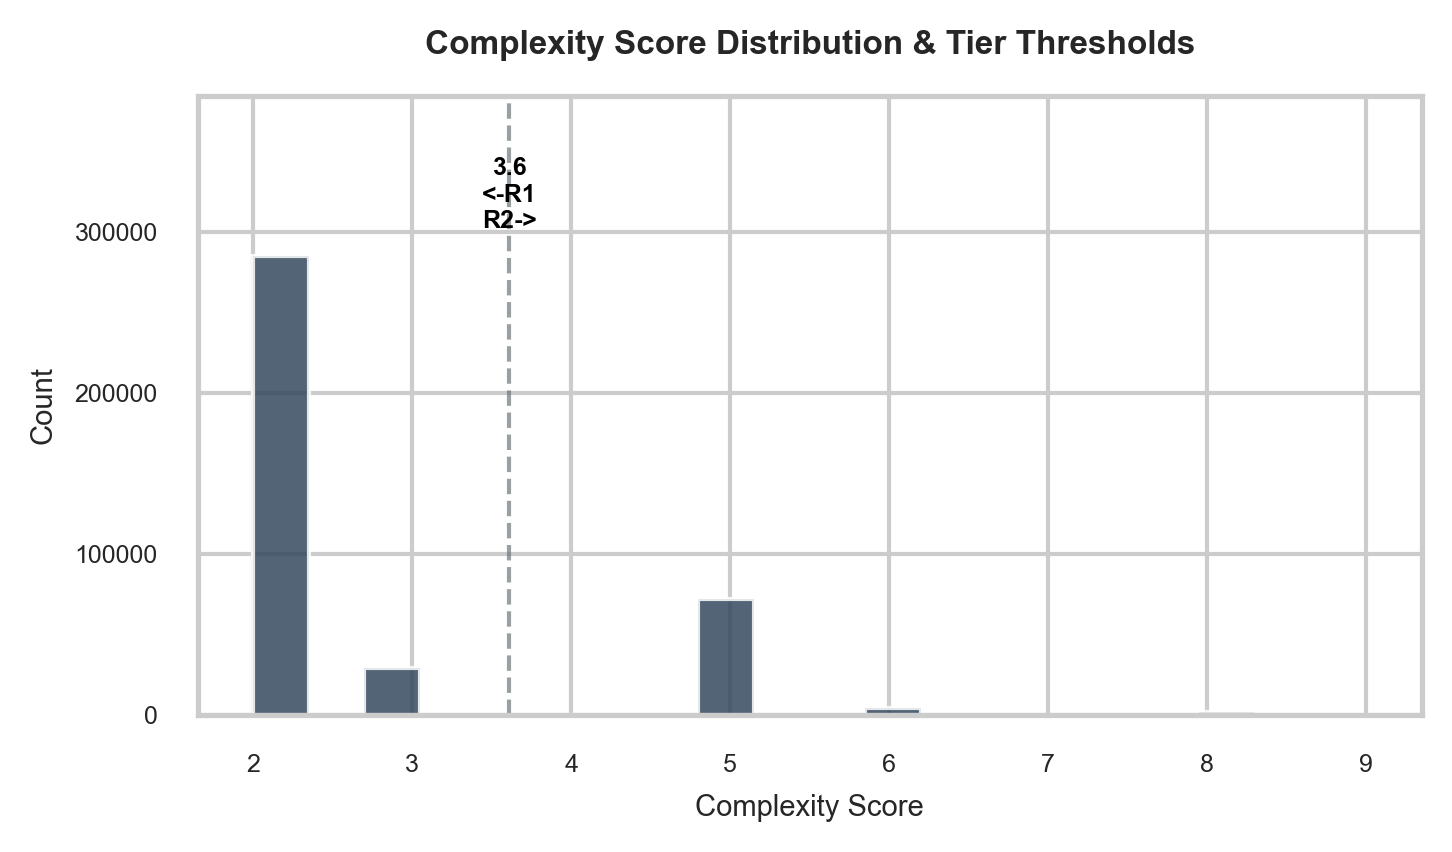


... Assigning Reviewer Tiers
... Saving Processed Datasets to harp/data/raw/harp_dataset
... Encoding and Saving to harp/data/raw/harp_dataset_encoded
... Calculating Reviewer Costs with mrr
Found costs: [2.365, 3.004]
Dataset generation complete.


In [4]:
with open("harp/config/data_config.yaml", "r") as f:
    config = yaml.safe_load(f)

generate_data(config=config)

In [ ]:
from torch.utils.data import DataLoader

from harp.data.class_dataset import HARPDataset
from harp.models.encoder import HARPEncoder
from harp.models.f_networks import MinimalFNet
from harp.data.encodings import get_vocab_size
from harp.models.csc import CSCSelector, calculate_csc_thresholds, CSC_Router

d = HARPDataset(
     reviewer_costs=[2.367, 3.006],
     mode="val"
)

val_loader = DataLoader(
     d, 
     batch_size=32,
     shuffle=True
)

m = HARPEncoder(
     encoding_dim=32, 
     numeric_dim=7, 
     num_enc_heads=4, 
     num_enc_layers=2, 
     dgns_vocab_size=get_vocab_size()["DGNS"], 
     prcdr_vocab_size=get_vocab_size()["PRCDR"]
)

f = MinimalFNet(
     encoder=m,
     input_dim = 32, 
     hidden_dims=[16, 8, 4],
     output_dim=1,
     dropout=0.1
)

g = CSCSelector(f, 3, 32, 2, 0)

print(calculate_csc_thresholds(
     g=g,
     data_loader=val_loader,
     n_reviewers=2,
))

router = CSC_Router(g, val_loader, 2, None, None)
router(d[:]["x_cat_dgns"], d[:]["x_cat_prcdr"], d[:]["x_num"])


[np.float32(-0.03810513), np.float32(-0.038250554), np.float32(-0.03863603)]
